# Part 2 — RFM Segmentation & Retention Strategy

**Snapshot:** 2025-09-30 | **Features:** pre-snapshot orders/tickets only

> **Charts:** Generated via `.venv` + `make_charts.py` (Anaconda matplotlib is broken on this PC).  
> First-time setup in terminal: `python -m venv .venv` then `.venv\Scripts\pip install -r requirements.txt`

## Phase 1 — Load & filter (leakage guardrails)

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

SNAPSHOT = pd.Timestamp('2025-09-30')
WINDOW_180_START = pd.Timestamp('2025-04-03')
WINDOW_90_START = pd.Timestamp('2025-07-02')
RECENCY_NO_ORDER = 999
ROOT = Path('.')

customers = pd.read_csv(ROOT / 'customers.csv')
orders = pd.read_csv(ROOT / 'orders.csv', parse_dates=['order_date'])
tickets = pd.read_csv(ROOT / 'support_tickets.csv', parse_dates=['ticket_date'])
web = pd.read_csv(ROOT / 'web_events_snapshot.csv')
intervention = pd.read_csv(ROOT / 'intervention_history.csv')
labels = pd.read_csv(ROOT / 'churn_labels.csv')

orders_pre = orders[orders['order_date'] <= SNAPSHOT].copy()
tickets_pre = tickets[tickets['ticket_date'] <= SNAPSHOT].copy()
orders_pre = orders_pre[~orders_pre['order_id'].str.endswith('_DUP', na=False)]
orders_pre = orders_pre.drop_duplicates(subset=['order_id'], keep='first')

assert (orders_pre['order_date'] > SNAPSHOT).sum() == 0
print('orders_pre rows:', len(orders_pre), '| max date:', orders_pre['order_date'].max())

base = customers.merge(web[['customer_id','sessions_30d','campaign_clicks_30d','last_visit_days_ago']], on='customer_id', how='left')
base = base.merge(intervention[['customer_id','last_campaign_received']], on='customer_id', how='left')
base = base.merge(labels[['customer_id','churn_next_60d']], on='customer_id', how='left')
for c in ['sessions_30d','campaign_clicks_30d']:
    base[c] = base[c].fillna(0)
print('base shape:', base.shape)
assert len(base) == 2400

orders_pre rows: 8128 | max date: 2025-09-30 00:00:00
base shape: (2400, 14)


## Phase 2 — RFM features (180-day window)

Window **2025-04-03 → 2025-09-30** aligns with capstone modeling snapshot and seasonal purchase cycles.

In [8]:
win = orders_pre[orders_pre['order_date'] >= WINDOW_180_START]
cust_ids = customers['customer_id']

last_order = orders_pre.groupby('customer_id')['order_date'].max().reindex(cust_ids)
recency = (SNAPSHOT - last_order).dt.days.fillna(RECENCY_NO_ORDER).astype(int)
frequency = win.groupby('customer_id').size().reindex(cust_ids, fill_value=0).astype(int)
monetary = win.groupby('customer_id')['gross_amount'].sum().reindex(cust_ids, fill_value=0.0)
return_rate_180d = win.groupby('customer_id')['returned'].mean().reindex(cust_ids, fill_value=0.0)
avg_discount_pct_180d = win.groupby('customer_id')['discount_pct'].mean().reindex(cust_ids, fill_value=0.0)

df = base.copy()
df['recency'] = recency.values
df['frequency'] = frequency.values
df['monetary'] = monetary.values
df['return_rate_180d'] = return_rate_180d.values
df['avg_discount_pct_180d'] = avg_discount_pct_180d.values
df[['recency','frequency','monetary']].describe()

,recency,frequency,monetary
count,2400.000000,2400.000000,2400.000000
mean,87.375833,1.594583,1183.794946
std,80.137473,1.184964,1057.615428
min,0.000000,0.000000,0.000000
25%,25.000000,1.000000,449.270000
50%,66.000000,1.000000,911.875000
75%,129.000000,2.000000,1681.510000
max,562.000000,8.000000,11655.310000


## Phase 3 — Non-RFM signals

In [9]:
tickets_90 = tickets_pre[tickets_pre['ticket_date'] >= WINDOW_90_START]
df['ticket_count_90d'] = tickets_90.groupby('customer_id').size().reindex(cust_ids, fill_value=0).astype(int).values
df['campaign_engaged'] = np.where(df['last_campaign_received'].fillna('none') == 'none', 'No Campaign', 'Engaged')

cols = ['recency','frequency','monetary','ticket_count_90d','sessions_30d','campaign_clicks_30d']
print(df[cols].corr().round(2))

                     recency  frequency  monetary  ticket_count_90d  \
recency                 1.00      -0.51     -0.42             -0.30   
frequency              -0.51       1.00      0.82              0.28   
monetary               -0.42       0.82      1.00              0.22   
ticket_count_90d       -0.30       0.28      0.22              1.00   
sessions_30d           -0.36       0.25      0.22              0.13   
campaign_clicks_30d    -0.04       0.07      0.06             -0.01   

                     sessions_30d  campaign_clicks_30d  
recency                     -0.36                -0.04  
frequency                    0.25                 0.07  
monetary                     0.22                 0.06  
ticket_count_90d             0.13                -0.01  
sessions_30d                 1.00                 0.25  
campaign_clicks_30d          0.25                 1.00  


## Phase 4 — Segments (quantile-based rules)

In [10]:
active = df[df['frequency'] > 0]
TH = {
    'recency_75': df['recency'].quantile(0.75),
    'recency_90': df['recency'].quantile(0.90),
    'freq_50': active['frequency'].quantile(0.50),
    'freq_75': active['frequency'].quantile(0.75),
    'monetary_80': df['monetary'].quantile(0.80),
    'monetary_70': df['monetary'].quantile(0.70),
    'monetary_30': df['monetary'].quantile(0.30),
    'monetary_50': df['monetary'].quantile(0.50),
    'discount_75': df['avg_discount_pct_180d'].quantile(0.75),
    'sessions_25': df['sessions_30d'].quantile(0.25),
    'recency_champion_max': int(df[df['frequency'] > 0]['recency'].quantile(0.25)),
}
print('Thresholds:', TH)

def assign_segment_v2(row, t):
    r, f, m = int(row['recency']), int(row['frequency']), float(row['monetary'])
    tickets, disc, sessions = int(row['ticket_count_90d']), float(row['avg_discount_pct_180d']), int(row['sessions_30d'])
    if f == 0 or r >= t['recency_90']:
        return 'Dormant'
    if m >= t['monetary_70'] and tickets >= 2:
        return 'High-Value Unhappy'
    if r <= t['recency_champion_max'] and f >= t['freq_75'] and m >= t['monetary_80']:
        return 'Champions'
    if disc >= t['discount_75'] and m <= t['monetary_30']:
        return 'Discount-Sensitive'
    if r > t['recency_75'] and f >= 2:
        return 'At-Risk'
    if f >= max(2, t['freq_50']) and tickets <= 1 and r <= t['recency_75']:
        return 'Loyal Customers'
    if sessions <= t['sessions_25'] and r > t['recency_champion_max']:
        return 'At-Risk'
    return 'Loyal Customers'

df['segment_name'] = df.apply(lambda r: assign_segment_v2(r, TH), axis=1)
print(df['segment_name'].value_counts())
print('\nChurn by segment:')
print(df.groupby('segment_name')['churn_next_60d'].mean().sort_values(ascending=False))

Thresholds: {'recency_75': np.float64(129.0), 'recency_90': np.float64(196.0), 'freq_50': np.float64(1.0), 'freq_75': np.float64(2.0), 'monetary_80': np.float64(1899.488), 'monetary_70': np.float64(1470.789), 'monetary_30': np.float64(517.4809999999999), 'monetary_50': np.float64(911.875), 'discount_75': np.float64(0.34), 'sessions_25': np.float64(2.0), 'recency_champion_max': 22}
segment_name
Loyal Customers       1429
At-Risk                311
Dormant                302
Discount-Sensitive     189
Champions              132
High-Value Unhappy      37
Name: count, dtype: int64

Churn by segment:
segment_name
Dormant               0.913907
At-Risk               0.713826
Discount-Sensitive    0.582011
Loyal Customers       0.357593
High-Value Unhappy    0.054054
Champions             0.045455
Name: churn_next_60d, dtype: float64


In [11]:
# Charts use project .venv (Anaconda matplotlib on this machine is corrupted)
import subprocess
import sys
from pathlib import Path

VENV_PY = Path(".venv/Scripts/python.exe")
if not VENV_PY.exists():
    VENV_PY = Path(".venv/bin/python")

if not VENV_PY.exists():
    raise FileNotFoundError(
        "Missing .venv. In a terminal run:\n"
        "  python -m venv .venv\n"
        "  .venv\\Scripts\\pip install pandas numpy matplotlib seaborn"
    )

print("Chart Python:", VENV_PY.resolve())

Chart Python: C:\Users\Keshav Verma\onediveNew\OneDrive\Desktop\TechStack\ALML\capstone project\part 2\part2_rfm_segmentation\.venv\Scripts\python.exe


## Phase 5 — Export `segments.csv` & charts

segments.csv rows: 2400
Saved charts to C:\Users\Keshav Verma\onediveNew\OneDrive\Desktop\TechStack\ALML\capstone project\part 2\part2_rfm_segmentation\charts

At-Risk and Dormant show highest churn; Champions lowest.


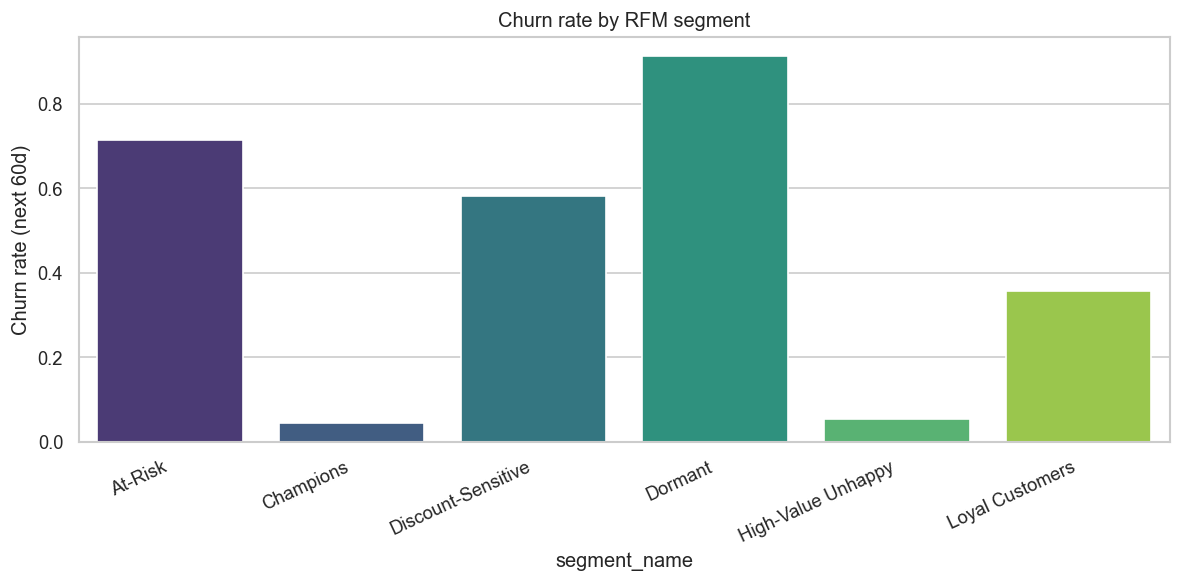

Champions and High-Value Unhappy drive top spend.


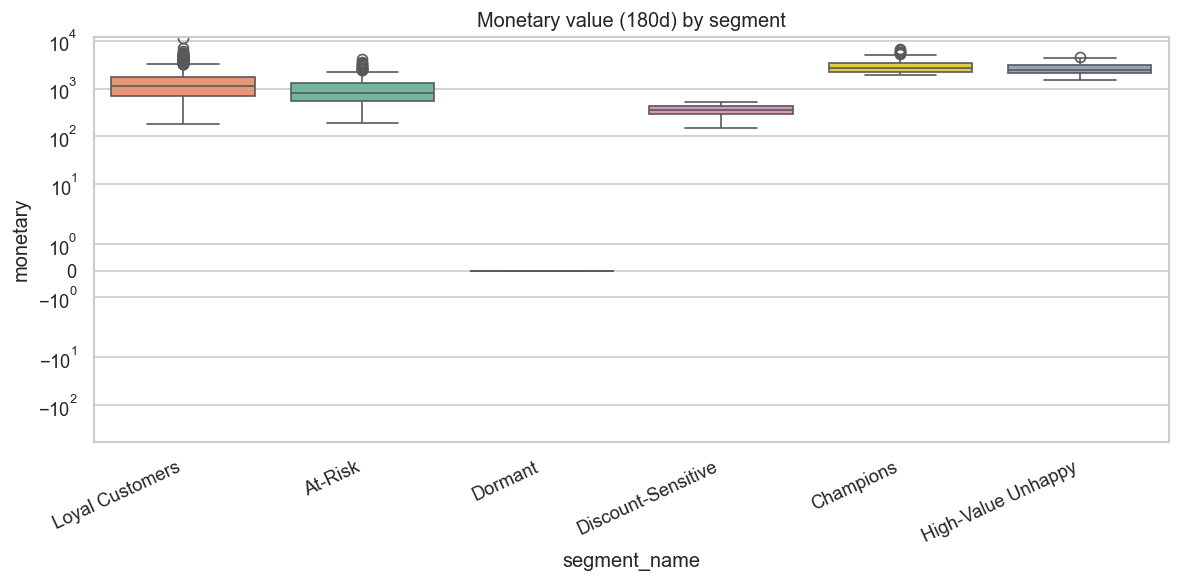

Champions cluster at low recency, high frequency.


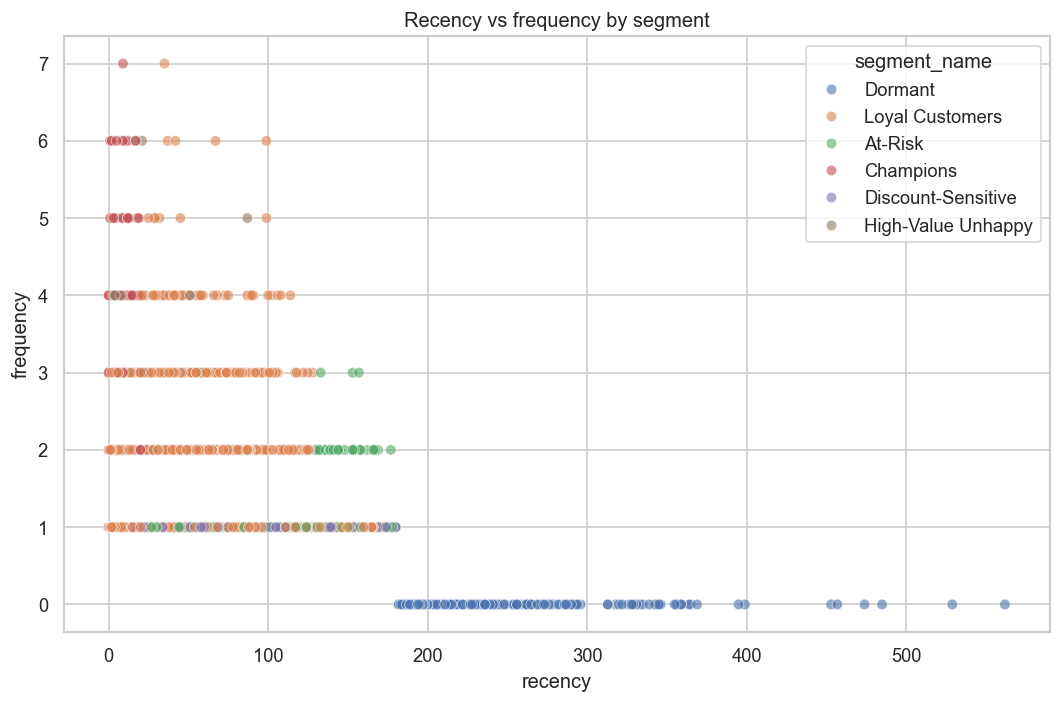

In [12]:
out = df[['customer_id','segment_name','recency','frequency','monetary','ticket_count_90d','sessions_30d','campaign_clicks_30d']]
out.to_csv('segments.csv', index=False)
print('segments.csv rows:', len(out))

# Build charts in .venv (clear Jupyter's inline MPLBACKEND for subprocess)
import os

chart_env = os.environ.copy()
chart_env["MPLBACKEND"] = "Agg"
result = subprocess.run(
    [str(VENV_PY.resolve()), "make_charts.py"],
    cwd=ROOT,
    capture_output=True,
    text=True,
    env=chart_env,
)
print(result.stdout)
if result.returncode != 0:
    raise RuntimeError(result.stderr or "make_charts.py failed")

from IPython.display import Image, display

CHARTS = ROOT / "charts"
insights = {
    "churn_by_segment.png": "At-Risk and Dormant show highest churn; Champions lowest.",
    "monetary_by_segment.png": "Champions and High-Value Unhappy drive top spend.",
    "recency_frequency_scatter.png": "Champions cluster at low recency, high frequency.",
}
for name, note in insights.items():
    path = CHARTS / name
    print(note)
    display(Image(filename=str(path)))

## Phase 8 — Validation checklist

In [13]:
seg = pd.read_csv('segments.csv')
checks = {
    'rows_2400': len(seg) == 2400,
    'required_cols': set(['customer_id','segment_name','recency','frequency','monetary','ticket_count_90d','sessions_30d','campaign_clicks_30d']).issubset(seg.columns),
    'segments_5plus': seg['segment_name'].nunique() >= 5,
    'no_post_snapshot_orders': (orders_pre['order_date'] > SNAPSHOT).sum() == 0,
}
for k, v in checks.items():
    print(f"[{'x' if v else ' '}] {k}: {v}")
print('\nSegment counts:\n', seg['segment_name'].value_counts())

[x] rows_2400: True
[x] required_cols: True
[x] segments_5plus: True
[x] no_post_snapshot_orders: True

Segment counts:
 segment_name
Loyal Customers       1429
At-Risk                311
Dormant                302
Discount-Sensitive     189
Champions              132
High-Value Unhappy      37
Name: count, dtype: int64
